In [162]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [34]:
RANDOM_STATE = 42

In [35]:
np.random.seed(RANDOM_STATE)

n_samples = 1000
n_features = 10

X = np.random.randn(n_samples, n_features)
coefficients = np.random.randn(n_features)
y = X @ coefficients+ 0.5 * np.random.randn(n_samples)

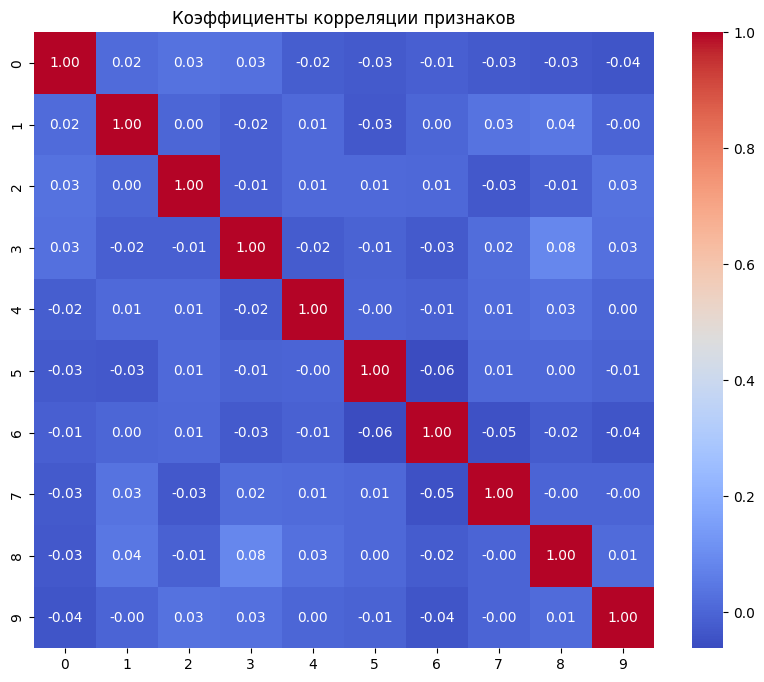

In [36]:
corr_matrix = np.corrcoef(X, rowvar=False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Коэффициенты корреляции признаков')
plt.show()

## Выводы:
Корреляция между признаками отсутствует, ни один из коэффициентов не превосходит по модулю 0.06.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [84]:
n_estimators = 20

bagging = BaggingRegressor(estimator=LinearRegression(), n_estimators=n_estimators, random_state=RANDOM_STATE)
bagging.fit(X_train, y_train)

BaggingRegressor(estimator=LinearRegression(), n_estimators=20, random_state=42)

In [83]:
y_pred = bagging.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE на тесте: {mse:.4f}")
print(f"R^2 на тесте: {r2:.4f}")

MSE на тесте: 0.2332
R^2 на тесте: 0.9646


## Выводы

Ансамбль показывает хорошее качество: MSE (0.2332) мала по сравнению с масштабом y(см. график ниже), $R^2$ близок к единице (0.9646), что говорит о том, что модель объясняет большую часть дисперсии целевой переменной.

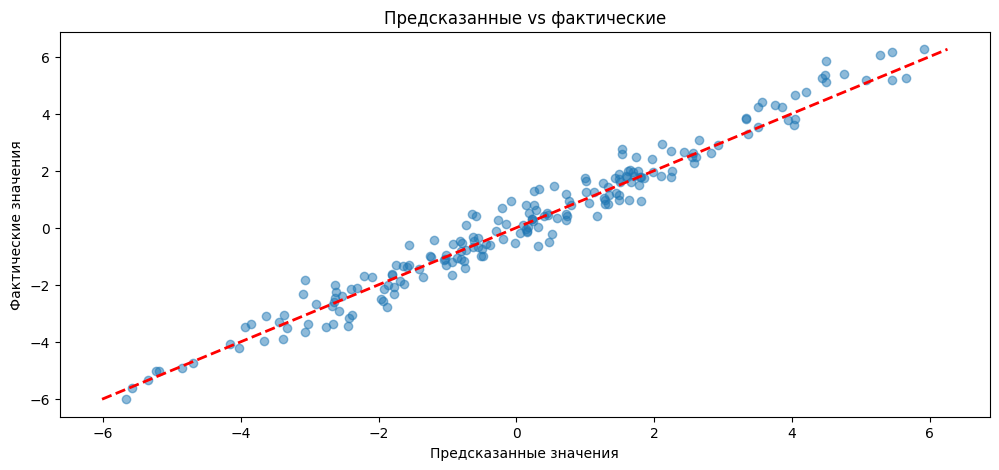

In [57]:
plt.figure(figsize=(12, 5))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Фактические значения')
plt.title('Предсказанные vs фактические')
plt.show()

In [53]:
residuals = y_test - y_pred

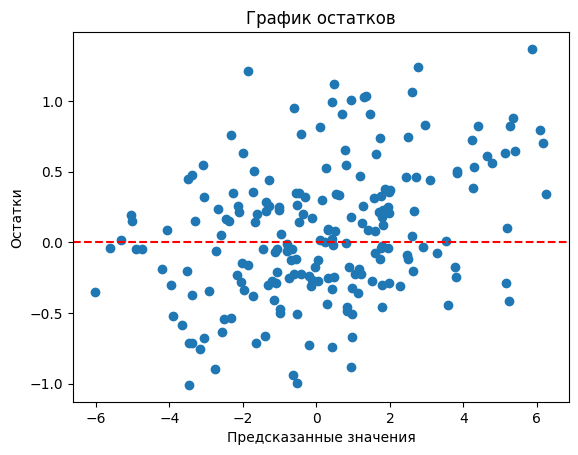

In [56]:
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('График остатков')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.show()

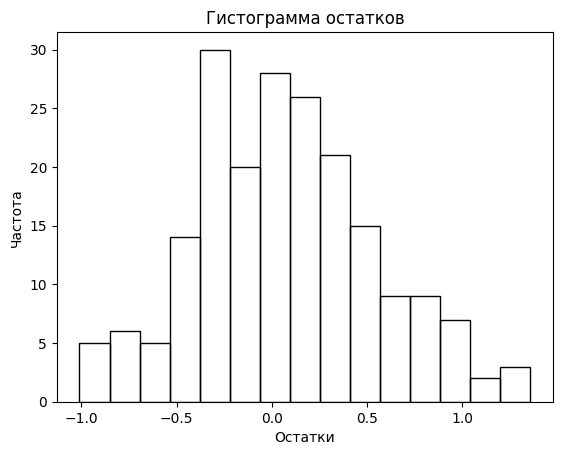

In [148]:
plt.hist(residuals, bins=15, fill=False)
plt.title("Гистограмма остатков")
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.show()

Text(0.5, 0, 'Остатки')

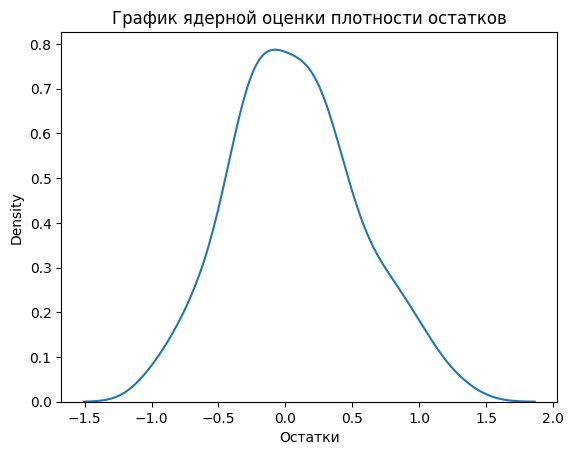

In [65]:
sns.kdeplot(residuals)
plt.title("График ядерной оценки плотности остатков")
plt.xlabel("Остатки")

In [163]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(shapiro_stat, shapiro_p )

0.9912201057637667 0.267299151125407


## Выводы

Из графиков видно:
1) Предсказания близки к истинным значениям целевой переменной.
2) Остатки распределны гомоскедатично: для всего промежутка значений целевой переменной дисперсия остатков ведет себя одинаково.
3) Остатки распределены нормально, что видно из гистограммы и ядерной оценки плотности и подтверждается тестом Шапиро (так как shapiro_p (0.2673) > 0.05)

In [80]:
data = pd.DataFrame(X, columns=[f'feat_{i+1}' for i in range(n_features)])
vif = pd.DataFrame()
vif['Feature'] = data.columns
vif['VIF'] = [variance_inflation_factor(data.values, i).round(4) for i in range(n_features)]

In [81]:
vif

,Feature,VIF
0,feat_1,1.0064
1,feat_2,1.0051
2,feat_3,1.0033
3,feat_4,1.0108
4,feat_5,1.0023
5,feat_6,1.0061
6,feat_7,1.0094
7,feat_8,1.0057
8,feat_9,1.0119
9,feat_10,1.0048


## Выводы

Все IVF близки к едиинице, что указывает на отсутсвие линейной зависимости между признаками.

In [118]:
coeffs = np.array([est.coef_ for est in bagging.estimators_])
mean_coeffs = coeffs.mean(0)
std_coeffs = coeffs.std(0)

In [120]:
mean_coeffs_df = pd.DataFrame((np.empty((n_features, 2))), index=data.columns, columns=['mean_coeffs', 'std_coeffs'])
mean_coeffs_df['mean_coeffs'] = mean_coeffs
mean_coeffs_df['std_coeffs'] = std_coeffs
mean_coeffs_df

,mean_coeffs,std_coeffs
feat_1,-0.690089,0.017876
feat_2,-0.306935,0.016130
feat_3,-0.585600,0.017101
feat_4,0.141898,0.015386
feat_5,1.188130,0.013554
feat_6,-0.765836,0.015647
feat_7,0.988451,0.017077
feat_8,-0.752601,0.019490
feat_9,-0.852299,0.018084
feat_10,0.794427,0.020114


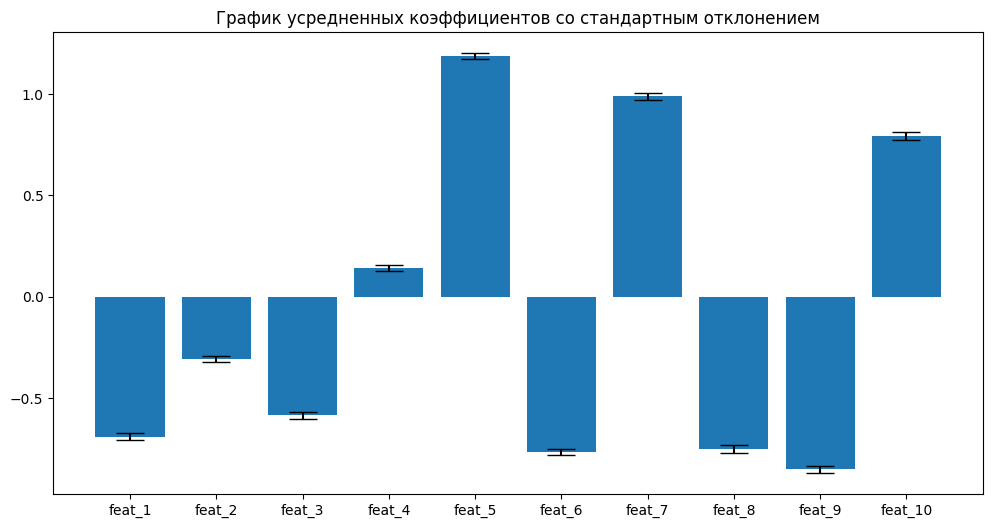

In [149]:
plt.figure(figsize=(12, 6))
plt.bar(x=mean_coeffs_df.index, height=mean_coeffs_df['mean_coeffs'], yerr=mean_coeffs_df['std_coeffs'], capsize=10)
plt.title('График усредненных коэффициентов со стандартным отклонением')
plt.show()


## Выводы:
Из графика усредненных коэффициентов видно, что для всех коэффициентов стандартное отклонение мало по сравнению со средним по моделям значениям, что указывает хорошую согласованность моделей в бэггинге. Так как базовой моделью является линейная регрессия без регуляризации, из значения коэффициентов мы можем однозначно делать выводе о том, как изменение значения коэффициента качесвтенно и количественно влияет на предсказываемую переменную.